# Assignment 1 - Abramov Aleksandr. Question 2

Construct a neural network with one hidden layer to solve the XOR gate problem.
Experiment with hidden layer sizes of 2, 3, and 4 neurons (using sigmoid activation) and compare training
accuracy. Explain why a single-layer network fails for XOR and how hidden layer size impacts the
network's ability to learn this non-linear pattern. Give your explanation about hidden layers and its
impact.

In [1]:
import typing

import tqdm
import torch
import matplotlib.figure
import matplotlib.pyplot as plt

torch.manual_seed(42)

X = torch.tensor(
    [[0, 0], [0, 1], [1, 0], [1, 1]], dtype = torch.float
)
y = torch.tensor(
    [[0], [1], [1], [0]], dtype = torch.float
)

def train(
    nn: torch.nn.Module,
    epochs: int = 10000,
    lr: float = 2.5,
    desc: typing.Optional[str] = None
) -> typing.Tuple[typing.List[float], typing.List[float]]:
    pbar = tqdm.trange(epochs, desc = desc)
    loss_history, accuracy_history = [], []
    for _ in pbar:
        pred_logits = nn(X) # Froward pass
        loss = torch.nn.functional.binary_cross_entropy(
            pred_logits, y
        )

        loss.backward() # Compute gradients
        for parameter in nn.parameters():
            parameter.data -= lr * parameter.grad # Update parameters
            parameter.grad.zero_() # Zero gradients for next iteration

        loss_history.append(loss.item())
        accuracy_history.append(
            ((pred_logits > 0.5) == y).float().mean().item()
        )
        pbar.set_postfix({
            'Loss': loss_history[-1],
            'Accuracy': accuracy_history[-1]
        })

    print("Prediction: ", nn(X).squeeze().tolist())
    return loss_history, accuracy_history

def try_and_show(
    models: typing.Dict[str, torch.nn.Module],
    epochs: int = 10000
) -> matplotlib.figure.Figure:
    fig, axes = plt.subplots(1, 2, figsize = (20, 3))

    for model, name in models:
        loss, accuracy = train(model, epochs, desc = name)
        axes[0].plot(loss, label = name)
        axes[1].plot(accuracy, label = name)
        
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha = 0.3)
        ax.legend()
    axes[0].set_title("Loss")
    axes[0].set_ylabel("Binary cross-entropy loss")
    axes[1].set_title("Accuracy")
    axes[1].set_ylabel("Accuracy")

### Experiment with the number of hidden layers

Firts, let's look at how the network will behave with different numbers of hidden layers. For simplicity, all hidden layers will contain the same number of neurons - 2.

1-layer network: 100%|██████████| 10000/10000 [00:12<00:00, 815.98it/s, Loss=0.693, Accuracy=0.5]


Prediction:  [0.5, 0.5, 0.5, 0.5]


2-layer network: 100%|██████████| 10000/10000 [00:12<00:00, 778.93it/s, Loss=0.000374, Accuracy=1]


Prediction:  [0.0003558591997716576, 0.9995046854019165, 0.9996671676635742, 0.0003123098867945373]


3-layer network: 100%|██████████| 10000/10000 [00:14<00:00, 671.18it/s, Loss=0.00014, Accuracy=1]


Prediction:  [0.00010215226939180866, 0.9998193383216858, 0.9998195767402649, 9.556215809425339e-05]


4-layer network: 100%|██████████| 10000/10000 [00:16<00:00, 615.85it/s, Loss=0.000445, Accuracy=1]


Prediction:  [0.000490655773319304, 0.9992377758026123, 0.9999567270278931, 0.0004846524680033326]


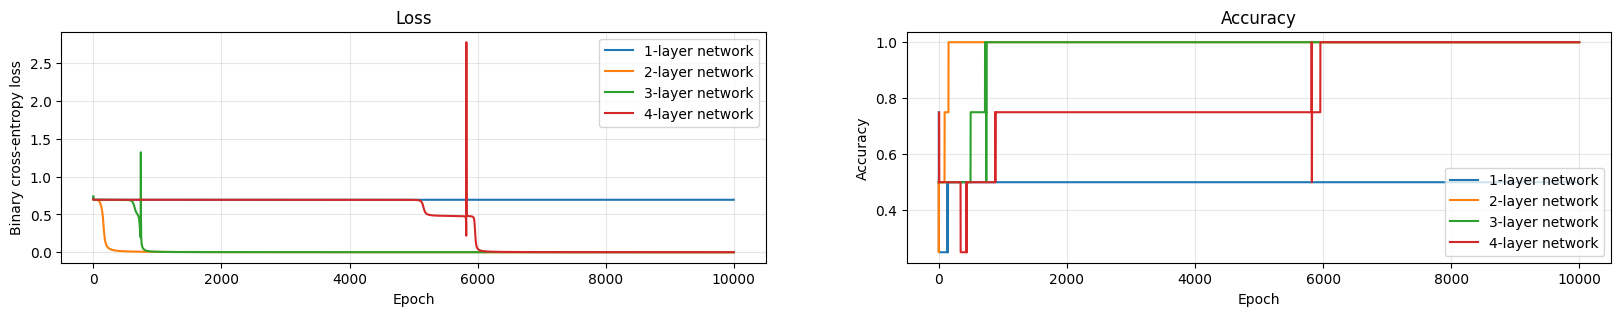

In [2]:
def make_n_layer_model(num_layers: int):
    return torch.nn.Sequential(
        *[
            torch.nn.Sequential(
                torch.nn.Linear(2, 2), torch.nn.Sigmoid()
            )
            for _ in range(num_layers - 1)
        ],
        torch.nn.Linear(2, 1), torch.nn.Sigmoid()
    )

try_and_show([
    (make_n_layer_model(num_layers), f'{num_layers}-layer network')
    for num_layers in range(1, 5)
])

A one-layer network is defined as $y = \sigma(Wx + b) = \sigma(w_1 x_1 + w_2 x_2 + b)$. So, the predictions for each input are as follows:
- $x_1 = 0, x_2 = 0 \Rightarrow y = \sigma(b), \text{target} = 0$
- $x_1 = 1, x_2 = 0 \Rightarrow y = \sigma(w_1 + b), \text{target} = 1$
- $x_1 = 0, x_2 = 1 \Rightarrow y = \sigma(w_2 + b), \text{target} = 1$
- $x_1 = 1, x_2 = 1 \Rightarrow y = \sigma(w_1 + w_2 + b), \text{target} = 0$

Suppose the object is classified as positive if $y \gt t$, where $t$ is some threshold. Since $\sigma(x)$ is monotonous, solving the problem perfectly requires the following conditions to hold for some threshold $q$:
$$
\begin{cases}
    b \le q & (1) \\
    w_1 + b \gt q & (2) \\
    w_2 + b \gt q & (3) \\
    w_1 + w_2 + b \le q & (4) \\
\end{cases}
$$
From $(2)$ and $(3)$, $w_1 + w_2 + 2b \gt 2q$. Accounting for $(1)$, $w_1 + w_2 + 2b + q \gt 2q + b$. Thus, $w_1 + w_2 + b \gt q$, which is a contradiction to $(4)$.

Therefore, the best accuracy one can expect from a one-layer network is $3 / 4$. A one-layer network is unable to solve the XOR gate problem, which is consistent with the theory: the problem is not linearly separable, and a one-layer network is a linear classifier that has a linear decision boundary and can solve only linearly-separable problems.

This is exactly what we see in the experiment above: a single-layer network produced constant, basically random predictions, and achieved only $50\%$ accuracy. Although theoretically the model could have achieved a $75\%$ accuracy, it is not the case in practice.

---

A two-layer network is defined as follows:
$$
\begin{cases}
    h_1 = \sigma(w_{11} x_1 + w_{12} x_2 + b_1) \\
    h_2 = \sigma(w_{21} x_1 + w_{22} x_2 + b_2) \\
    y = \sigma(w_1 h_1 + w_2 h_2 + b) \\
\end{cases}
$$
If one substitutes $w_{11} = 1$, $w_{12} = -1$, $b_1 = -2$, $w_{21} = -1$, $w_{22} = 1$, $b_2 = -2$, $w_1 = 1$, $w_2 = 1$, $b = 0$, then:
$$
\begin{cases}
    x_1 = 0, x_2 = 0 &\Rightarrow& h_1 = \sigma(-2) \approx 0.12, h_2 = \sigma(-2) \approx 0.12 &\Rightarrow y \approx \sigma(0.24) \\
    x_1 = 0, x_2 = 1 &\Rightarrow& h_1 = \sigma(-3) \approx 0.05, h_2 = \sigma(-1) \approx 0.27 &\Rightarrow y \approx \sigma(0.32) \\
    x_1 = 1, x_2 = 0 &\Rightarrow& h_1 = \sigma(-1) \approx 0.27, h_2 = \sigma(-3) \approx 0.05 &\Rightarrow y \approx \sigma(0.32) \\
    x_1 = 1, x_2 = 1 &\Rightarrow& h_1 = \sigma(-2) \approx 0.12, h_2 = \sigma(-2) \approx 0.12 &\Rightarrow y \approx \sigma(0.24) \\
\end{cases}
$$
Thus, a threshold of $\sigma(0.28)$ leads to perfect classification, which was impossible previously. Indeed, adding hidden layers to the network makes the model non-linear, which alleviates the problem of a single-layer network, and allows it to solve the XOR gate problem.

And this is consistent with the practical results obtained above: a two-layer network converges relatively quickly and successfully reaches the perfect accuracy of $100\%$.

---

Introducing more layers does not affect the theoretical ability of the network to solve the problem, since additional layers, in the worst case, can just transfer the input as the output without transformation, except for the monotonous non-linearity: 
$$
\begin{cases}
    h_1^{i+1} = \sigma(1 \cdot h_1^i + 0 \cdot h_2^i + 0) \\
    h_2^{i+1} = \sigma(0 \cdot h_1^i + 1 \cdot h_2^i + 0) \\
\end{cases}
$$

However, additional layers introduce more parameters, which may lead to gradient decay and generally complicate the gradient landscape of the network, making it harder to train. This is exactly what was observed in the experiments: both the 3-layer and 4-layer networks took more training epochs to converge and achieve the perfect accuracy than the 2-layer network.

### Experiment with size of hidden layer in a 2-layer network

Next, let's take a closer look at a two-layer network and consider various sizes of the hidden layer.

Hidden layer size 1: 100%|██████████| 1000/1000 [00:01<00:00, 730.11it/s, Loss=0.481, Accuracy=0.75]


Prediction:  [0.3365361988544464, 0.33306047320365906, 0.9954853653907776, 0.3349165916442871]


Hidden layer size 2: 100%|██████████| 1000/1000 [00:01<00:00, 784.36it/s, Loss=0.00505, Accuracy=1]


Prediction:  [0.006266490090638399, 0.995457649230957, 0.9954621195793152, 0.004776638932526112]


Hidden layer size 3: 100%|██████████| 1000/1000 [00:01<00:00, 841.90it/s, Loss=0.00369, Accuracy=1]


Prediction:  [0.0035571607295423746, 0.9941761493682861, 0.9975365400314331, 0.002882144181057811]


Hidden layer size 4: 100%|██████████| 1000/1000 [00:01<00:00, 860.63it/s, Loss=0.00325, Accuracy=1]


Prediction:  [0.00268495618365705, 0.9961199760437012, 0.997563362121582, 0.003960922826081514]


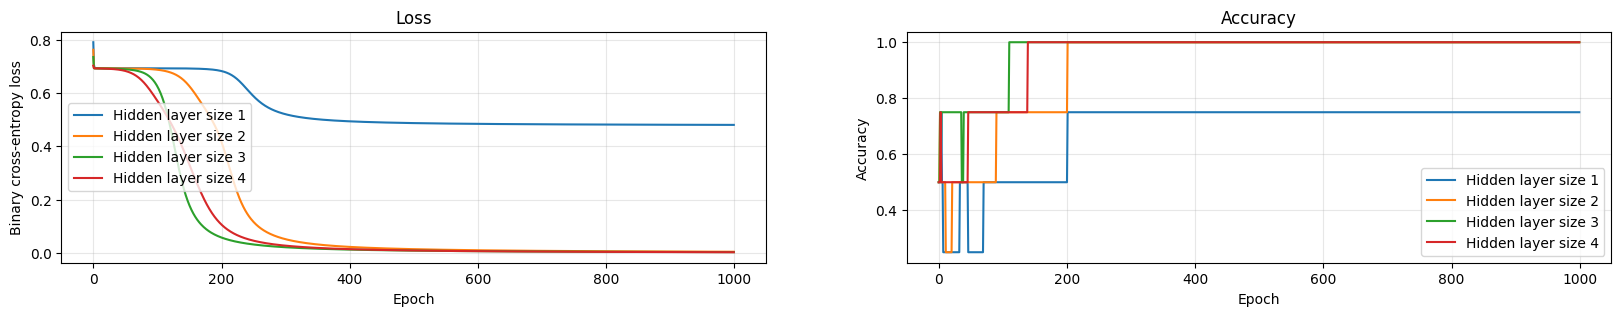

In [3]:
def make_two_layer_model(hidden_size: int):
    return torch.nn.Sequential(
        torch.nn.Linear(2, hidden_size), torch.nn.Sigmoid(),
        torch.nn.Linear(hidden_size, 1), torch.nn.Sigmoid()
    )

try_and_show([
    (
        make_two_layer_model(hidden_size),
        f'Hidden layer size {hidden_size}'
    )
    for hidden_size in range(1, 5)
], epochs = 1000)

First, the network with 1 neuron in the hidden layer did not converge to the correct answer, which is, in fact, expected. In this case, the output is fully determined by the first layer, and the second one is simply a linear transformation of the output, which does not introduce additional information in the network. Mathematically, if the first layer is $h = \sigma(w_1 x_1 + w_2 x_2 + b)$, and the second one is $y = \sigma(w h + c)$, correctly classifying all four examples would require the following:
$$
\begin{cases}
    \sigma(b) \le q & (1) \\
    \sigma(w_1 + b) \gt q & (2) \\
    \sigma(w_2 + b) \gt q & (3) \\
    \sigma(w_1 + w_2 + b) \le q & (4) \\
\end{cases}
$$
If one redefines $t = \log \left( \dfrac{1 - q}{q} \right)$, the equations become totally equivalent to the ones obtained previously for a single-layer network:
$$
\begin{cases}
    b \le t & (1) \\
    w_1 + b \gt t & (2) \\
    w_2 + b \gt t & (3) \\
    w_1 + w_2 + b \le t & (4) \\
\end{cases}
$$
Thus, a two-layer network with one neuron in the hidden layer has equivalent predicting power to the single-layer network and cannot solve a non-linear XOR gate problem, which is observed in the experiment. Interestingly, despite the theoretical results and in contrast to the single-layer network, the two-layer network achieved the expected maximum of $75\%$ accuracy.

---

With 2 neurons in the hidden layer, the model is equivalent to the 2-layer network considered previously. Expectedly, it converged to the perfect accuracy relatively quickly.

---

Finally, adding more neurons to the hidden layer is defined as follows:
$$
\begin{cases}
    h_1 = \sigma(w_{11} x_1 + w_{12} x_2 + b_1) \\
    \dots \\
    h_n = \sigma(w_{n1} x_1 + w_{n2} x_2 + b_n) \\
    y = \sigma(w_1 h_1 + \ldots + w_n h_n + b) \\
\end{cases}
$$
If one considers $w_3 = \ldots = w_n = 0$, the additional neurons are basically disabled, and the overall network is equivalent to the one with 2 neurons in the hidden layer. Thus, the models with 3 and 4 neurons are at least as powerful as the one with two neurons, and are expected two achieve perfect accuracy as well.

And the theoretical expectation is consistent with practical results: both networks successfully solved the XOR gate problem. Moreover, additional neurons allowed them to capture the necessary patterns more quickly and achieve the desired result in less epochs, although adding the fourth neuron did not improve that due to a small size of the dataset.